In [2]:
import pandas as pd
import json

# Read the CSV file
df = pd.read_csv('enhanced_anxiety_dataset.csv')

# List of anxiety levels
anxiety_levels = list(range(1, 11))

# Final JSON output
results_json = {
    "anxiety_feature_summary": {}
}

# Analyze for each anxiety level 1 to 10
for level in anxiety_levels:
    df_level = df[df['Anxiety Level (1-10)'] == level]
    total_level_count = len(df_level)
    total_samples = len(df)

    # Store ranking for features
    feature_rankings = []

    # Exclude target variable
    features = [col for col in df.columns if col != 'Anxiety Level (1-10)']

    for feature in features:
        value_counts_level = df_level[feature].value_counts()
        total_value_counts = df[feature].value_counts()

        max_count = 0
        max_value = None
        max_percentage = 0
        max_total = 0

        for value in total_value_counts.index:
            count_in_level = int(value_counts_level.get(value, 0))
            total_count = int(total_value_counts[value])

            if total_count > 0:
                percentage = round((count_in_level / total_count) * 100, 2)
            else:
                percentage = 0

            # detect max
            if count_in_level > max_count:
                max_count = count_in_level
                max_value = value
                max_percentage = percentage
                max_total = total_count

        feature_rankings.append({
            "feature": feature,
            "value": str(max_value),
            "count": max_count,
            "total": max_total,
            "percentage": max_percentage
        })

    # Sort features by strongest association
    feature_rankings.sort(key=lambda x: x["count"], reverse=True)

    # Take top 5 features
    top_5 = feature_rankings[:5]

    # Save into final JSON structure
    results_json["anxiety_feature_summary"][f"Anxiety_Level_{level}"] = {
        "total_samples_with_this_level": total_level_count,
        "percentage_of_dataset": round((total_level_count / total_samples) * 100, 2),
        "top_5_features": top_5
    }

# Save JSON file
output_file = "anxiety_top_5_features_all_levels.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(results_json, f, ensure_ascii=False, indent=2)

print(f"JSON saved to {output_file}")


JSON saved to anxiety_top_5_features_all_levels.json


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Load original dataset
print("="*70)
print("HYBRID DATASET GENERATION (WITH & WITHOUT CATEGORICAL)")
print("="*70)
print("\nLoading original dataset...")
df = pd.read_csv('enhanced_anxiety_dataset.csv')
df.columns = df.columns.str.strip()
target = 'Anxiety Level (1-10)'

# Separate numeric and categorical features
all_cols = df.columns.drop(target, errors='ignore').tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target, errors='ignore').tolist()
categorical_cols = [col for col in all_cols if col not in numeric_cols]

print(f"Number of numeric features: {len(numeric_cols)}")
print(f"Numeric features: {numeric_cols}")
print(f"\nNumber of categorical features: {len(categorical_cols)}")
print(f"Categorical features: {categorical_cols}\n")

# Display original class distribution
print("Original dataset class distribution:")
original_counts = df[target].value_counts().sort_index()
print(original_counts)
print(f"Total original samples: {len(df)}\n")

# Separate classes 1-4 and 5-10
print("="*70)
print("STEP 1: Keeping original data for classes 1-4")
print("="*70)
classes_1_to_4 = df[df[target].isin([1, 2, 3, 4])].copy()
print(f"Classes 1-4 samples: {len(classes_1_to_4)}")
print("Class distribution:")
print(classes_1_to_4[target].value_counts().sort_index())

# Generate synthetic data for classes 5-10
print("\n" + "="*70)
print("STEP 2: Generating additional samples for classes 5-10")
print("="*70)

synthetic_data_with_categorical = []
synthetic_data_numeric_only = []

# Define samples per class: 5->300, 6->400, 7-10->600
samples_dict = {5: 300, 6: 400, 7: 600, 8: 600, 9: 600, 10: 600}

for class_label in [5, 6, 7, 8, 9, 10]:
    samples_per_class = samples_dict[class_label]
    print(f"\nProcessing Anxiety Level {class_label}...")
    
    # Get original data for this class
    class_data = df[df[target] == class_label]
    original_class_samples = len(class_data)
    print(f"  Original samples: {original_class_samples}")
    print(f"  Generating additional samples: {samples_per_class}")
    
    # ============ NUMERIC FEATURES ============
    class_numeric = class_data[numeric_cols]
    numeric_samples = np.zeros((samples_per_class, len(numeric_cols)))
    
    for i, feature in enumerate(numeric_cols):
        feature_values = class_numeric[feature].dropna().values
        
        if len(feature_values) < 2:
            numeric_samples[:, i] = np.mean(feature_values) if len(feature_values) > 0 else 0
            continue
        
        try:
            kde = stats.gaussian_kde(feature_values)
            generated = kde.resample(samples_per_class).flatten()
            min_val = feature_values.min()
            max_val = feature_values.max()
            generated = np.clip(generated, min_val, max_val)
            numeric_samples[:, i] = generated
        except:
            mean = np.mean(feature_values)
            std = np.std(feature_values)
            if std == 0:
                std = 0.01
            generated = np.random.normal(mean, std, samples_per_class)
            min_val = feature_values.min()
            max_val = feature_values.max()
            generated = np.clip(generated, min_val, max_val)
            numeric_samples[:, i] = generated
    
    # ============ CATEGORICAL FEATURES ============
    categorical_samples = {}
    
    for cat_feature in categorical_cols:
        cat_values = class_data[cat_feature].dropna()
        
        if len(cat_values) == 0:
            # No data, use most common value from entire dataset
            categorical_samples[cat_feature] = [df[cat_feature].mode()[0]] * samples_per_class
        else:
            # Calculate distribution
            value_counts = cat_values.value_counts(normalize=True)
            categories = value_counts.index.tolist()
            probabilities = value_counts.values
            
            # Sample based on distribution
            categorical_samples[cat_feature] = np.random.choice(
                categories, 
                size=samples_per_class, 
                p=probabilities
            )
    
    # Create dataframe WITH categorical features
    synthetic_with_cat = pd.DataFrame(numeric_samples, columns=numeric_cols)
    for cat_feature in categorical_cols:
        synthetic_with_cat[cat_feature] = categorical_samples[cat_feature]
    synthetic_with_cat[target] = class_label
    synthetic_data_with_categorical.append(synthetic_with_cat)
    
    # Create dataframe WITHOUT categorical features (numeric only)
    synthetic_numeric = pd.DataFrame(numeric_samples, columns=numeric_cols)
    synthetic_numeric[target] = class_label
    synthetic_data_numeric_only.append(synthetic_numeric)
    
    print(f"  Successfully generated {samples_per_class} synthetic samples")

# ============ DATASET 1: WITH CATEGORICAL ============
print("\n" + "="*70)
print("STEP 3A: Creating dataset WITH categorical features")
print("="*70)

synthetic_5_to_10_cat = pd.concat(synthetic_data_with_categorical, ignore_index=True)
print(f"Total synthetic samples (classes 5-10): {len(synthetic_5_to_10_cat)}")

original_5_to_10 = df[df[target].isin([5, 6, 7, 8, 9, 10])].copy()
print(f"Total original samples (classes 5-10): {len(original_5_to_10)}")

hybrid_with_categorical = pd.concat([
    classes_1_to_4,
    original_5_to_10,
    synthetic_5_to_10_cat
], ignore_index=True)

hybrid_with_categorical = hybrid_with_categorical.sample(frac=1, random_state=42).reset_index(drop=True)

output_file_cat = 'hybrid_dataset_with_categorical.csv'
hybrid_with_categorical.to_csv(output_file_cat, index=False)
print(f"Dataset WITH categorical saved to: {output_file_cat}")
print(f"Shape: {hybrid_with_categorical.shape}")

# ============ DATASET 2: WITHOUT CATEGORICAL ============
print("\n" + "="*70)
print("STEP 3B: Creating dataset WITHOUT categorical features")
print("="*70)

synthetic_5_to_10_numeric = pd.concat(synthetic_data_numeric_only, ignore_index=True)
print(f"Total synthetic samples (classes 5-10): {len(synthetic_5_to_10_numeric)}")

# Remove categorical features from original data
classes_1_to_4_numeric = classes_1_to_4[numeric_cols + [target]].copy()
original_5_to_10_numeric = original_5_to_10[numeric_cols + [target]].copy()

hybrid_without_categorical = pd.concat([
    classes_1_to_4_numeric,
    original_5_to_10_numeric,
    synthetic_5_to_10_numeric
], ignore_index=True)

hybrid_without_categorical = hybrid_without_categorical.sample(frac=1, random_state=42).reset_index(drop=True)

output_file_no_cat = 'hybrid_dataset_without_categorical.csv'
hybrid_without_categorical.to_csv(output_file_no_cat, index=False)
print(f"Dataset WITHOUT categorical saved to: {output_file_no_cat}")
print(f"Shape: {hybrid_without_categorical.shape}")

# ============ SUMMARY ============
print("\n" + "="*70)
print("DATASET GENERATION SUMMARY")
print("="*70)

print("\nDATASET 1 (WITH CATEGORICAL):")
print(f"  Total samples: {len(hybrid_with_categorical)}")
print(f"  Features: {len(numeric_cols)} numeric + {len(categorical_cols)} categorical")
print(f"  Class distribution:")
print(hybrid_with_categorical[target].value_counts().sort_index())

print("\nDATASET 2 (WITHOUT CATEGORICAL):")
print(f"  Total samples: {len(hybrid_without_categorical)}")
print(f"  Features: {len(numeric_cols)} numeric only")
print(f"  Class distribution:")
print(hybrid_without_categorical[target].value_counts().sort_index())

print("\n" + "="*70)
print("BOTH DATASETS GENERATED SUCCESSFULLY!")
print("="*70)

SCATTER PLOT: STRESS LEVEL VS SLEEP HOURS
Total samples plotted: 11000
Stress Level range: 1 - 10
Sleep Hours range: 2.3 - 11.3
Correlation coefficient: -0.177

Plot saved as: stress_vs_sleep_plot.png


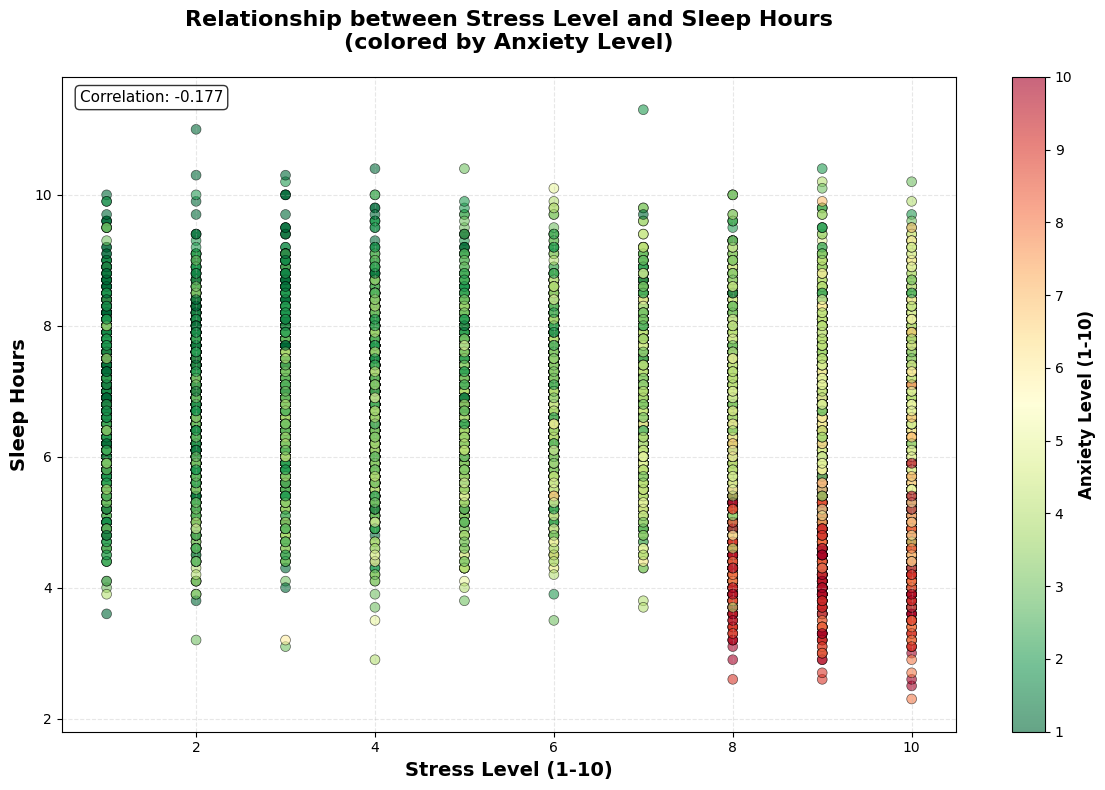

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('enhanced_anxiety_dataset.csv')

# Extract features
stress_level = df['Stress Level (1-10)']
sleep_hours = df['Sleep Hours']
anxiety_level = df['Anxiety Level (1-10)']

# Create scatter plot
plt.figure(figsize=(12, 8))

# Create scatter plot with color based on anxiety level
scatter = plt.scatter(stress_level, sleep_hours, 
                     c=anxiety_level, 
                     cmap='RdYlGn_r',  # Red-Yellow-Green reversed (red=high anxiety)
                     s=50, 
                     alpha=0.6,
                     edgecolors='black',
                     linewidth=0.5)

# Add colorbar to show anxiety levels
colorbar = plt.colorbar(scatter)
colorbar.set_label('Anxiety Level (1-10)', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel('Stress Level (1-10)', fontsize=14, fontweight='bold')
plt.ylabel('Sleep Hours', fontsize=14, fontweight='bold')
plt.title('Relationship between Stress Level and Sleep Hours\n(colored by Anxiety Level)', 
          fontsize=16, fontweight='bold', pad=20)

# Grid for better readability
plt.grid(True, alpha=0.3, linestyle='--')

# Set axis limits
plt.xlim(0.5, 10.5)
plt.ylim(df['Sleep Hours'].min() - 0.5, df['Sleep Hours'].max() + 0.5)

# Add statistics text
correlation = stress_level.corr(sleep_hours)
plt.text(0.02, 0.98, f'Correlation: {correlation:.3f}', 
         transform=plt.gca().transAxes,
         fontsize=11,
         verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Tight layout
plt.tight_layout()

# Save plot
plt.savefig('stress_vs_sleep_plot.png', dpi=300, bbox_inches='tight')
print("=" * 80)
print("SCATTER PLOT: STRESS LEVEL VS SLEEP HOURS")
print("=" * 80)
print(f"Total samples plotted: {len(df)}")
print(f"Stress Level range: {stress_level.min()} - {stress_level.max()}")
print(f"Sleep Hours range: {sleep_hours.min():.1f} - {sleep_hours.max():.1f}")
print(f"Correlation coefficient: {correlation:.3f}")
print(f"\nPlot saved as: stress_vs_sleep_plot.png")
print("=" * 80)

# Show plot
plt.show()

In [1]:
import pandas as pd

# Read CSV file
file_path = 'enhanced_anxiety_dataset.csv'

# Read the first line to get expected column count
with open(file_path, 'r', encoding='utf-8') as f:
    header = f.readline().strip()
    expected_cols = len(header.split(','))

print("=" * 80)
print("CHECKING FOR MISSING VALUES BY ROW LENGTH")
print("=" * 80)
print(f"Expected number of columns: {expected_cols}")
print("=" * 80)

# Check each row
problematic_rows = []
line_number = 1  # Start from 1 (header is line 1)

with open(file_path, 'r', encoding='utf-8') as f:
    next(f)  # Skip header
    
    for idx, line in enumerate(f, start=2):  # Start from line 2 (first data row)
        cols = line.strip().split(',')
        # Remove empty strings and count non-empty columns
        non_empty_cols = [col for col in cols if col.strip() != '']
        actual_cols = len(non_empty_cols)
        
        if actual_cols != expected_cols or len(cols) != expected_cols:
            problematic_rows.append({
                'line_number': idx,
                'expected_columns': expected_cols,
                'actual_columns': len(cols),
                'non_empty_columns': actual_cols,
                'missing_columns': expected_cols - actual_cols,
                'row_content': line.strip()[:100]  # First 100 chars
            })

# Print results
if len(problematic_rows) == 0:
    print("\n[OK] NO MISSING VALUES DETECTED!")
    print("All rows have the correct number of columns.")
    print(f"Total rows checked: {idx - 1}")
else:
    print(f"\n[ERROR] MISSING VALUES DETECTED!")
    print(f"Found {len(problematic_rows)} problematic rows:\n")
    
    for row in problematic_rows:
        print(f"Line {row['line_number']}:")
        print(f"  Expected: {row['expected_columns']} columns")
        print(f"  Found: {row['actual_columns']} columns (including empty)")
        print(f"  Non-empty: {row['non_empty_columns']} columns")
        print(f"  Missing: {row['missing_columns']} columns")
        print(f"  Preview: {row['row_content']}")
        print()

# Additional check using pandas
print("\n" + "=" * 80)
print("VERIFICATION USING PANDAS")
print("=" * 80)

df = pd.read_csv(file_path)
print(f"DataFrame shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nMissing values per column:")
missing_summary = df.isnull().sum()
if missing_summary.sum() == 0:
    print("[OK] No NaN/NULL values detected in DataFrame")
else:
    print(missing_summary[missing_summary > 0])

print("\n" + "=" * 80)
print("FINAL RESULT:")
if len(problematic_rows) == 0 and missing_summary.sum() == 0:
    print("[OK] Dataset is clean - No missing values found!")
else:
    print("[ERROR] Dataset has issues - Please review the problematic rows above")
print("=" * 80)

CHECKING FOR MISSING VALUES BY ROW LENGTH
Expected number of columns: 19

[OK] NO MISSING VALUES DETECTED!
All rows have the correct number of columns.
Total rows checked: 11000

VERIFICATION USING PANDAS
DataFrame shape: 11000 rows × 19 columns

Missing values per column:
[OK] No NaN/NULL values detected in DataFrame

FINAL RESULT:
[OK] Dataset is clean - No missing values found!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.naive_bayes import GaussianNB

np.random.seed(42)

# ============ LOGISTIC REGRESSION WITH COST TRACKING ============
class LogisticRegression:
    def __init__(self, lr=0.1, iterations=1000):
        self.lr = lr
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def compute_cost(self, y, y_pred):
        m = len(y)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        cost = -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))
        return cost

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        self.cost_history = []
        for i in range(self.iterations):
            z = X @ self.weights + self.bias
            y_pred = self.sigmoid(z)
            cost = self.compute_cost(y, y_pred)
            self.cost_history.append(cost)
            dw = (X.T @ (y_pred - y)) / n_samples
            db = np.mean(y_pred - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        z = X @ self.weights + self.bias
        return (self.sigmoid(z) >= 0.5).astype(int)

# ============ DATA PREPARATION ============
def create_stratified_test(df, target_col, test_size=2000):
    test_samples = []
    class_counts = df[target_col].value_counts()
    for cls in sorted(df[target_col].unique()):
        n = int((class_counts[cls] / len(df)) * test_size)
        sampled = df[df[target_col] == cls].sample(n=min(n, len(df[df[target_col] == cls])), random_state=42)
        test_samples.append(sampled)
    test_df = pd.concat(test_samples).sample(frac=1, random_state=42).reset_index(drop=True)
    train_df = df.drop(test_df.index).reset_index(drop=True)
    return train_df, test_df

def prepare_features(df, target_col, encoders=None):
    df = df.copy()
    y = (df[target_col] > 4).astype(int)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
    X_numeric = df[numeric_cols].values
    if len(categorical_cols) > 0:
        X_cat = df[categorical_cols].copy()
        if encoders is None:
            encoders = {}
            for col in categorical_cols:
                le = LabelEncoder()
                X_cat[col] = le.fit_transform(X_cat[col].astype(str))
                encoders[col] = le
        else:
            for col in categorical_cols:
                le = encoders[col]
                X_cat[col] = X_cat[col].astype(str).apply(lambda x: x if x in le.classes_ else le.classes_[0])
                X_cat[col] = le.transform(X_cat[col])
        X = np.hstack([X_numeric, X_cat.values])
        return X, y, encoders
    return X_numeric, y, None

# ============ TRAIN & EVALUATE ============
def train_evaluate(df, name, target_col, lr=0.1, iterations=1000, test_size=2000, model_type='logistic'):
    print(f"\n{'='*50}\n{name} | Model={model_type.upper()}")
    if model_type == 'logistic':
        print(f"LR={lr}, Iterations={iterations}")
    print(f"{'='*50}")
    train_df, test_df = create_stratified_test(df, target_col, test_size)
    print(f"Original target distribution in train:")
    print(train_df[target_col].value_counts().sort_index())
    print(f"\nOriginal target distribution in test:")
    print(test_df[target_col].value_counts().sort_index())
    X_train, y_train, encoders = prepare_features(train_df, target_col, encoders=None)
    X_test, y_test, _ = prepare_features(test_df, target_col, encoders=encoders)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print(f"\nAfter binarization:")
    print(f"Train: {X_train.shape}, Classes - 0: {sum(y_train==0)}, 1: {sum(y_train==1)}")
    print(f"Test: {X_test.shape}, Classes - 0: {sum(y_test==0)}, 1: {sum(y_test==1)}")

    if model_type == 'logistic':
        model = LogisticRegression(lr=lr, iterations=iterations)
        model.fit(X_train, y_train)
        cost_history = model.cost_history
    else:
        model = GaussianNB()
        model.fit(X_train, y_train)
        cost_history = []

    y_pred = model.predict(X_test)
    results = {
        'name': name,
        'model_type': model_type,
        'lr': lr if model_type == 'logistic' else None,
        'iterations': iterations if model_type == 'logistic' else None,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'cm': confusion_matrix(y_test, y_pred),
        'cost_history': cost_history
    }
    print(f"\nMetrics:")
    print(f"Accuracy: {results['accuracy']:.4f}")
    print(f"Precision: {results['precision']:.4f}")
    print(f"Recall: {results['recall']:.4f}")
    print(f"F1-Score: {results['f1']:.4f}")
    if model_type == 'logistic':
        print(f"Final Cost: {results['cost_history'][-1]:.4f}")
    print(f"\nPredictions distribution - 0: {sum(y_pred==0)}, 1: {sum(y_pred==1)}")
    return results

# ============ VISUALIZATION ============
def plot_combined_results(lr_results, nb_results):
    fig = plt.figure(figsize=(20, 14))
    ax1 = plt.subplot(3, 3, (1, 3))
    datasets = ['Original', 'Hybrid WITH Cat', 'Hybrid WITHOUT Cat']
    x = np.arange(len(datasets))
    width = 0.15
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    colors_lr = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
    colors_nb = ['#9b59b6', '#e67e22', '#1abc9c', '#34495e']
    for i, metric in enumerate(metrics):
        lr_values = [r[metric] for r in lr_results]
        nb_values = [r[metric] for r in nb_results]
        ax1.bar(x + i*width*2, lr_values, width, label=f'LR - {metric.capitalize()}', color=colors_lr[i], alpha=0.8)
        ax1.bar(x + i*width*2 + width, nb_values, width, label=f'NB - {metric.capitalize()}', color=colors_nb[i], alpha=0.8, hatch='//')
    ax1.set_xlabel('Dataset', fontsize=13, weight='bold')
    ax1.set_ylabel('Score', fontsize=13, weight='bold')
    ax1.set_title('Logistic Regression vs Naive Bayes - Overall Metrics Comparison', fontsize=15, weight='bold')
    ax1.set_xticks(x + width * 3.5)
    ax1.set_xticklabels(datasets, fontsize=11)
    ax1.legend(ncol=2, fontsize=9, loc='lower right')
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_ylim([0, 1.1])

    for i, r in enumerate(lr_results):
        ax = plt.subplot(3, 3, i+4)
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], cbar=False)
        ax.set_title(f"LR: {datasets[i]}\nF1: {r['f1']:.3f}", fontsize=11, weight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)

    for i, r in enumerate(nb_results):
        ax = plt.subplot(3, 3, i+7)
        sns.heatmap(r['cm'], annot=True, fmt='d', cmap='Purples', ax=ax, xticklabels=['Low', 'High'], yticklabels=['Low', 'High'], cbar=False)
        ax.set_title(f"NB: {datasets[i]}\nF1: {r['f1']:.3f}", fontsize=11, weight='bold')
        ax.set_xlabel('Predicted', fontsize=10)
        ax.set_ylabel('Actual', fontsize=10)

    plt.tight_layout()
    plt.show()

def plot_cost_curve(cost_results, title, x_label='Iterations'):
    plt.figure(figsize=(12, 6))
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    for i, result in enumerate(cost_results):
        label = result['label']
        iterations = range(1, len(result['cost_history']) + 1)
        plt.plot(iterations, result['cost_history'], label=label, color=colors[i], linewidth=2.5)
    plt.xlabel(x_label, fontsize=13)
    plt.ylabel('Cost (Cross-Entropy)', fontsize=13)
    plt.title(title, fontsize=15, weight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

def plot_iteration_comparison(iter_cost_results):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
    colors = ['#3498db', '#e74c3c', '#2ecc71']
    titles = ['100 Iterations', '500 Iterations', '1000 Iterations']
    for idx, result in enumerate(iter_cost_results):
        ax = axes[idx]
        iterations = list(range(1, len(result['cost_history']) + 1))
        ax.plot(iterations, result['cost_history'], color=colors[idx], linewidth=3)
        ax.set_title(titles[idx], fontsize=14, weight='bold')
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_xlim(0, len(iterations))
        ax.grid(True, alpha=0.3, linestyle='--')
        if idx == 0:
            ax.set_ylabel('Cost (Cross-Entropy)', fontsize=13)
    fig.suptitle('Cost vs. Iterations (LR=0.1) - Separate Horizontal Axes', fontsize=16, weight='bold', y=1.02)
    plt.tight_layout()
    plt.subplots_adjust(top=0.88, wspace=0.15)
    plt.show()

PART 1: Testing Different Learning Rates on Original Dataset (LR Only)

Original Dataset | Model=LOGISTIC
LR=0.01, Iterations=1000
Original target distribution in train:
Anxiety Level (1-10)
1.0      850
2.0     1445
3.0     1957
4.0     2011
5.0     1320
6.0      502
7.0      101
8.0      290
9.0      265
10.0     263
Name: count, dtype: int64

Original target distribution in test:
Anxiety Level (1-10)
1.0     188
2.0     319
3.0     437
4.0     439
5.0     296
6.0     112
7.0      22
8.0      66
9.0      59
10.0     58
Name: count, dtype: int64

After binarization:
Train: (9004, 18), Classes - 0: 6263, 1: 2741
Test: (1996, 18), Classes - 0: 1383, 1: 613

Metrics:
Accuracy: 0.8382
Precision: 0.7821
Recall: 0.6558
F1-Score: 0.7134
Final Cost: 0.3729

Predictions distribution - 0: 1482, 1: 514

Original Dataset | Model=LOGISTIC
LR=0.05, Iterations=1000
Original target distribution in train:
Anxiety Level (1-10)
1.0      850
2.0     1445
3.0     1957
4.0     2011
5.0     1320
6.0      50

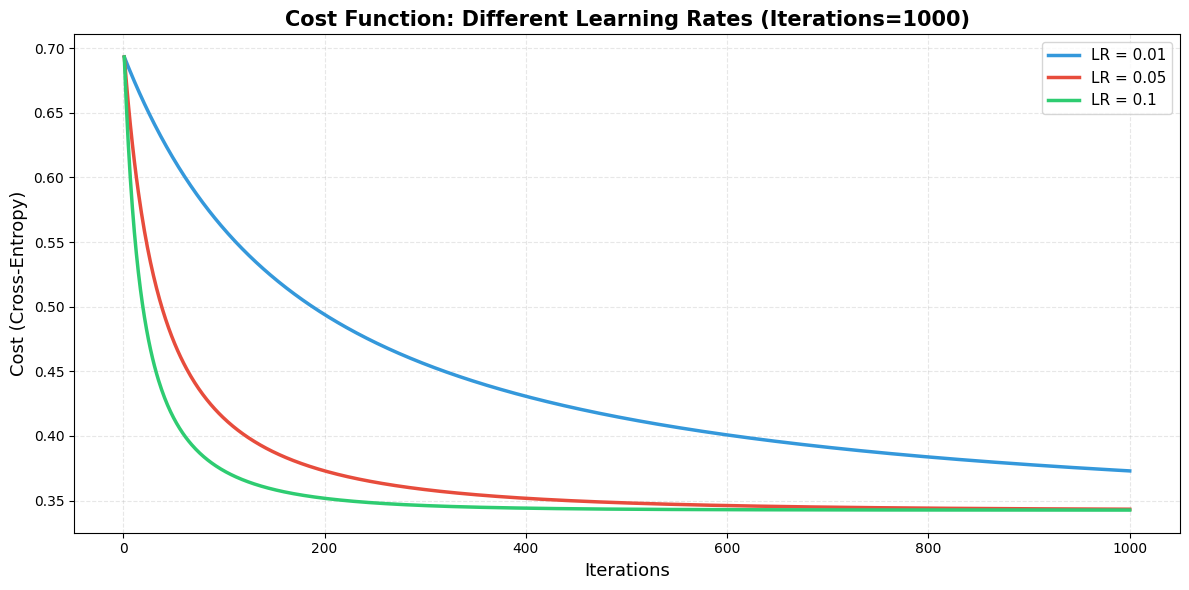


PART 2: Testing Different Iterations on Original Dataset (LR Only)

Original Dataset | Model=LOGISTIC
LR=0.1, Iterations=100
Original target distribution in train:
Anxiety Level (1-10)
1.0      850
2.0     1445
3.0     1957
4.0     2011
5.0     1320
6.0      502
7.0      101
8.0      290
9.0      265
10.0     263
Name: count, dtype: int64

Original target distribution in test:
Anxiety Level (1-10)
1.0     188
2.0     319
3.0     437
4.0     439
5.0     296
6.0     112
7.0      22
8.0      66
9.0      59
10.0     58
Name: count, dtype: int64

After binarization:
Train: (9004, 18), Classes - 0: 6263, 1: 2741
Test: (1996, 18), Classes - 0: 1383, 1: 613

Metrics:
Accuracy: 0.8382
Precision: 0.7821
Recall: 0.6558
F1-Score: 0.7134
Final Cost: 0.3730

Predictions distribution - 0: 1482, 1: 514

Original Dataset | Model=LOGISTIC
LR=0.1, Iterations=500
Original target distribution in train:
Anxiety Level (1-10)
1.0      850
2.0     1445
3.0     1957
4.0     2011
5.0     1320
6.0      502
7.0  

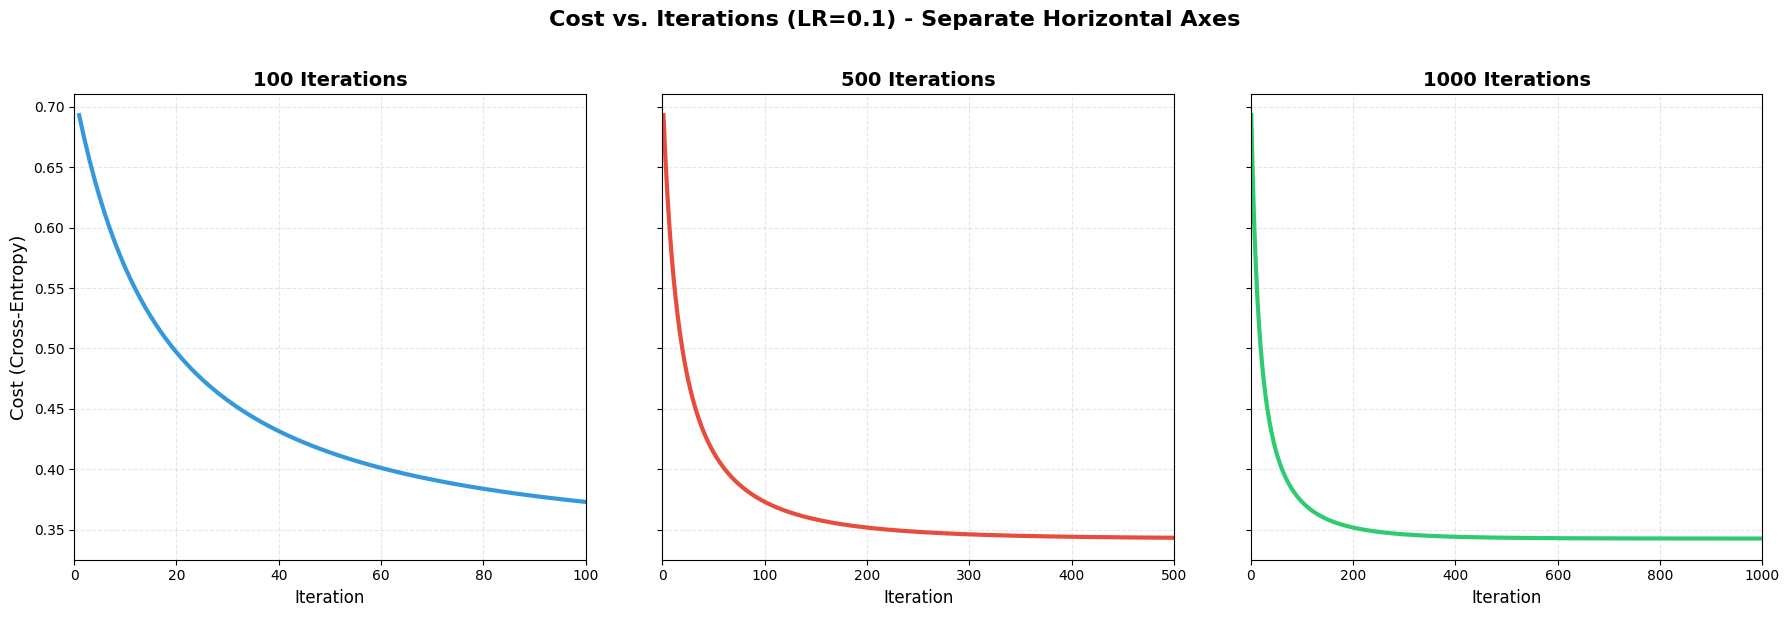

In [3]:
target = 'Anxiety Level (1-10)'
original_df = pd.read_csv('enhanced_anxiety_dataset.csv')
original_df.columns = original_df.columns.str.strip()

print("="*70)
print("PART 1: Testing Different Learning Rates on Original Dataset (LR Only)")
print("="*70)

lr_cost_results = []
for lr_val in [0.01, 0.05, 0.1]:
    result = train_evaluate(original_df, "Original Dataset", target, lr=lr_val, iterations=1000, model_type='logistic')
    lr_cost_results.append({
        'label': f'LR = {lr_val}',
        'cost_history': result['cost_history']
    })

plot_cost_curve(lr_cost_results, 'Cost Function: Different Learning Rates (Iterations=1000)', 'Iterations')

print("\n" + "="*70)
print("PART 2: Testing Different Iterations on Original Dataset (LR Only)")
print("="*70)

iter_cost_results = []
for iter_val in [100, 500, 1000]:
    result = train_evaluate(original_df, "Original Dataset", target, lr=0.1, iterations=iter_val, model_type='logistic')
    iter_cost_results.append({
        'label': f'Iterations = {iter_val}',
        'cost_history': result['cost_history']
    })

plot_iteration_comparison(iter_cost_results)


PART 3: Comparing Logistic Regression vs Naive Bayes on 3 Datasets

--- LOGISTIC REGRESSION ---

Original Dataset | Model=LOGISTIC
LR=0.1, Iterations=1000
Original target distribution in train:
Anxiety Level (1-10)
1.0      850
2.0     1445
3.0     1957
4.0     2011
5.0     1320
6.0      502
7.0      101
8.0      290
9.0      265
10.0     263
Name: count, dtype: int64

Original target distribution in test:
Anxiety Level (1-10)
1.0     188
2.0     319
3.0     437
4.0     439
5.0     296
6.0     112
7.0      22
8.0      66
9.0      59
10.0     58
Name: count, dtype: int64

After binarization:
Train: (9004, 18), Classes - 0: 6263, 1: 2741
Test: (1996, 18), Classes - 0: 1383, 1: 613

Metrics:
Accuracy: 0.8357
Precision: 0.7684
Recall: 0.6656
F1-Score: 0.7133
Final Cost: 0.3426

Predictions distribution - 0: 1465, 1: 531

Hybrid WITH Categorical | Model=LOGISTIC
LR=0.1, Iterations=1000
Original target distribution in train:
Anxiety Level (1-10)
1.0      896
2.0     1484
3.0     2056
4.0   

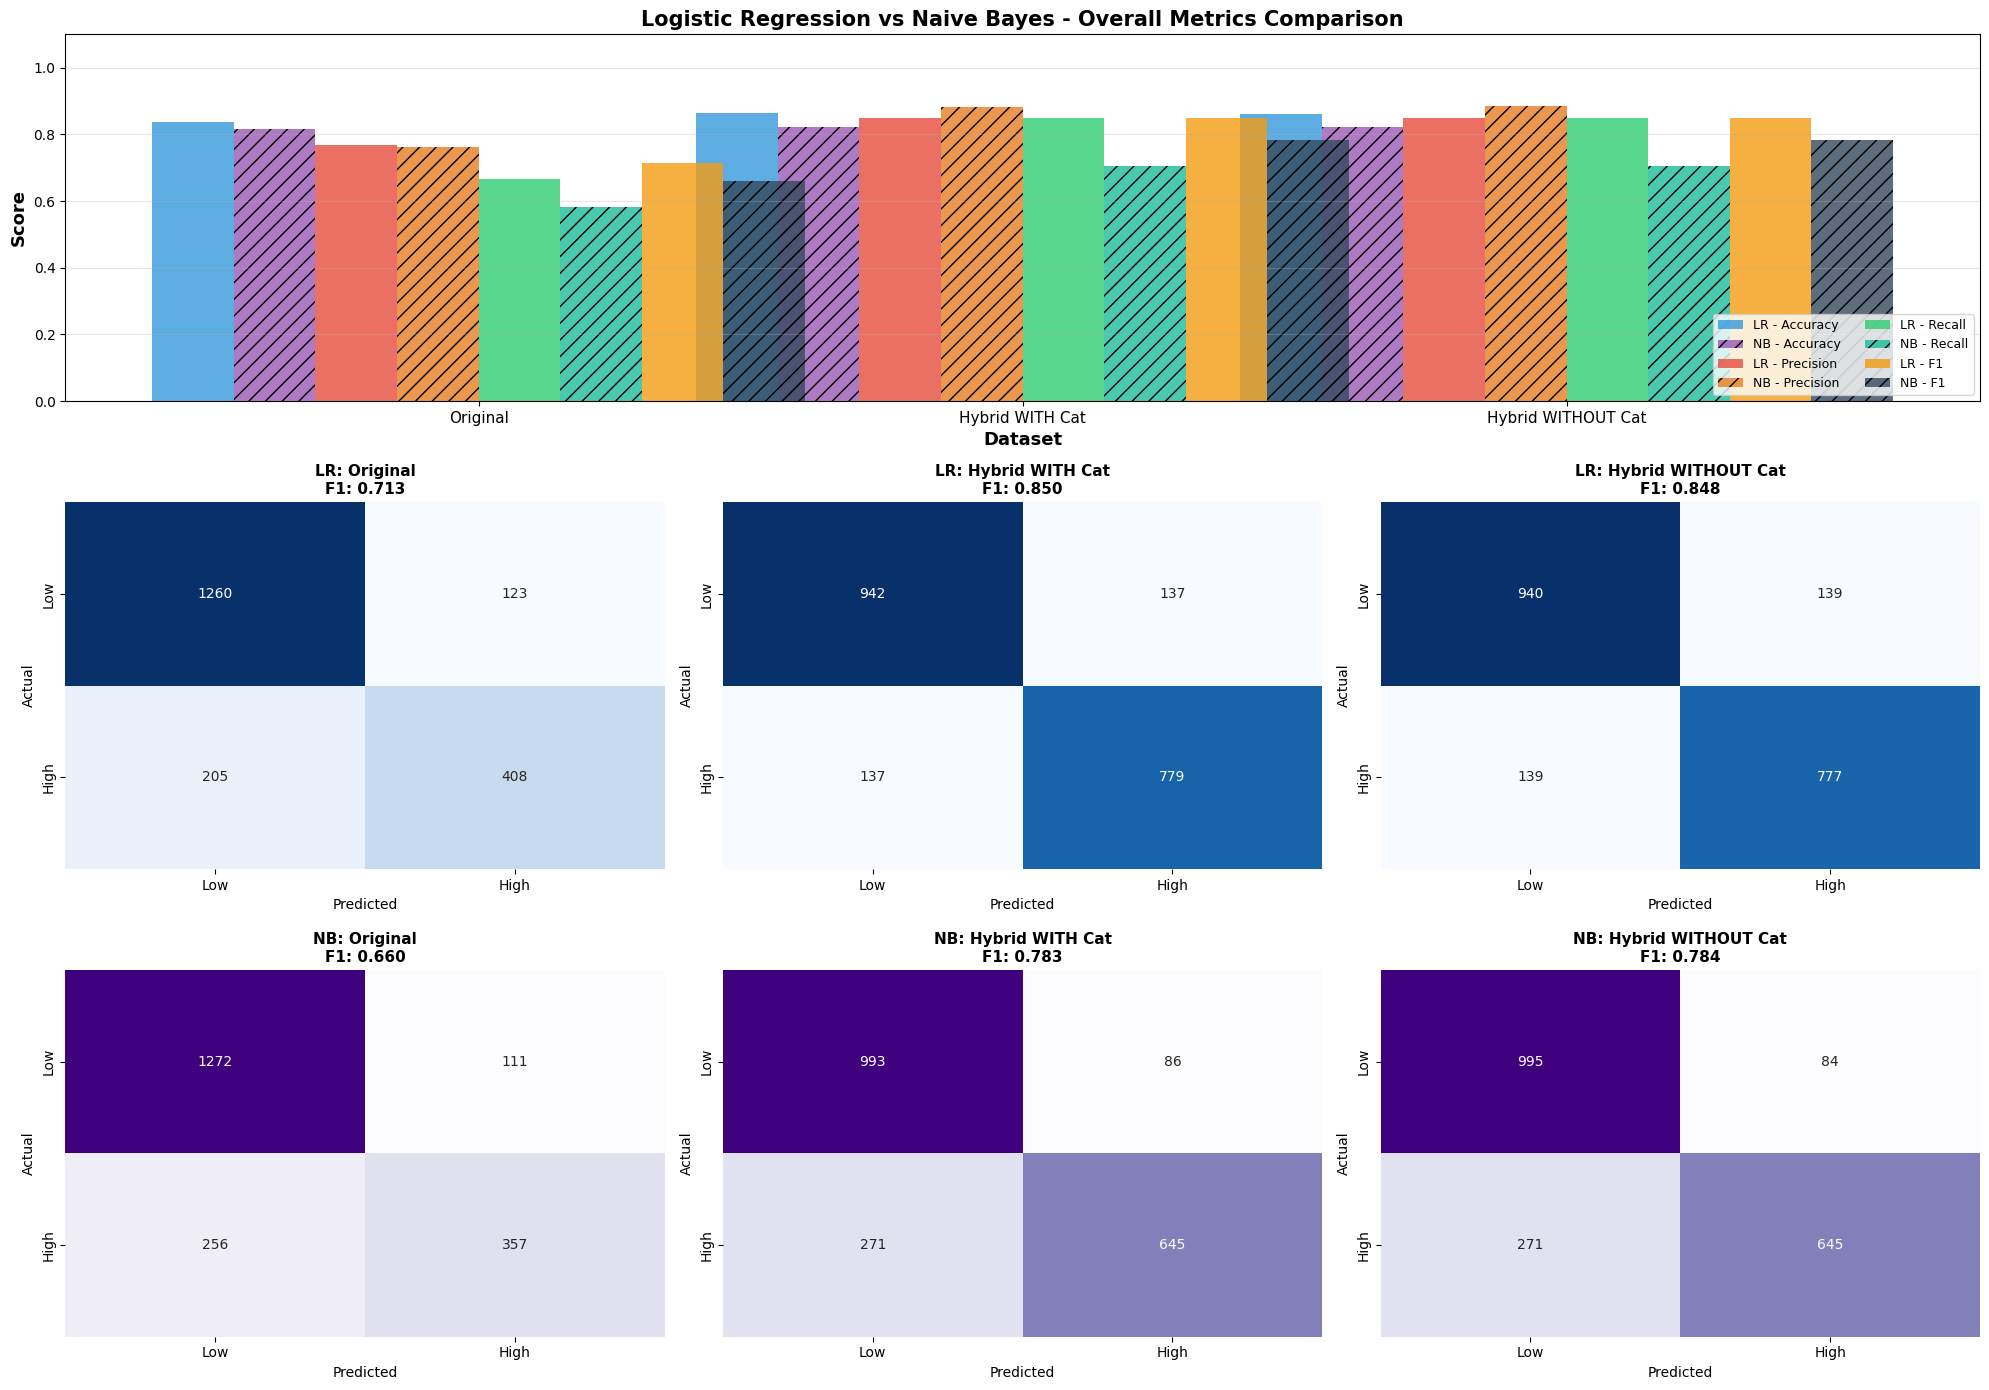

In [4]:
print("\n" + "="*70)
print("PART 3: Comparing Logistic Regression vs Naive Bayes on 3 Datasets")
print("="*70)

hybrid_with = pd.read_csv('hybrid_dataset_with_categorical.csv')
hybrid_with.columns = hybrid_with.columns.str.strip()
hybrid_without = pd.read_csv('hybrid_dataset_without_categorical.csv')
hybrid_without.columns = hybrid_without.columns.str.strip()

print("\n--- LOGISTIC REGRESSION ---")
lr_results = []
lr_results.append(train_evaluate(original_df, "Original Dataset", target, lr=0.1, iterations=1000, model_type='logistic'))
lr_results.append(train_evaluate(hybrid_with, "Hybrid WITH Categorical", target, lr=0.1, iterations=1000, model_type='logistic'))
lr_results.append(train_evaluate(hybrid_without, "Hybrid WITHOUT Categorical", target, lr=0.1, iterations=1000, model_type='logistic'))

print("\n--- NAIVE BAYES ---")
nb_results = []
nb_results.append(train_evaluate(original_df, "Original Dataset", target, model_type='naive_bayes'))
nb_results.append(train_evaluate(hybrid_with, "Hybrid WITH Categorical", target, model_type='naive_bayes'))
nb_results.append(train_evaluate(hybrid_without, "Hybrid WITHOUT Categorical", target, model_type='naive_bayes'))

comparison_data = []
for lr_r, nb_r in zip(lr_results, nb_results):
    comparison_data.append({
        'Dataset': lr_r['name'],
        'LR_Acc': f"{lr_r['accuracy']:.4f}",
        'NB_Acc': f"{nb_r['accuracy']:.4f}",
        'LR_Prec': f"{lr_r['precision']:.4f}",
        'NB_Prec': f"{nb_r['precision']:.4f}",
        'LR_Rec': f"{lr_r['recall']:.4f}",
        'NB_Rec': f"{nb_r['recall']:.4f}",
        'LR_F1': f"{lr_r['f1']:.4f}",
        'NB_F1': f"{nb_r['f1']:.4f}"
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nFINAL COMPARISON:")
print(comparison_df.to_string(index=False))

best_lr = max(lr_results, key=lambda x: x['f1'])
best_nb = max(nb_results, key=lambda x: x['f1'])
overall_best = max([best_lr, best_nb], key=lambda x: x['f1'])

print(f"\n*** Best Logistic Regression: {best_lr['name']} | F1: {best_lr['f1']:.4f}")
print(f"*** Best Naive Bayes: {best_nb['name']} | F1: {best_nb['f1']:.4f}")
print(f"*** OVERALL BEST MODEL: {overall_best['model_type'].upper()} on {overall_best['name']} | F1: {overall_best['f1']:.4f}")

plot_combined_results(lr_results, nb_results)

In [5]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

print("\n" + "="*70)
print("PART 4: Sklearn Logistic Regression vs Naive Bayes on 3 Datasets")
print("="*70)

def train_evaluate_sklearn(df, name, target_col, test_size=2000):
    train_df, test_df = create_stratified_test(df, target_col, test_size)
    X_train, y_train, encoders = prepare_features(train_df, target_col, encoders=None)
    X_test, y_test, _ = prepare_features(test_df, target_col, encoders=encoders)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = SklearnLogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results = {
        'name': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'cm': confusion_matrix(y_test, y_pred)
    }
    return results

print("\n--- SKLEARN LOGISTIC REGRESSION ---")
sklearn_lr_results = []
sklearn_lr_results.append(train_evaluate_sklearn(original_df, "Original Dataset", target))
sklearn_lr_results.append(train_evaluate_sklearn(hybrid_with, "Hybrid WITH Categorical", target))
sklearn_lr_results.append(train_evaluate_sklearn(hybrid_without, "Hybrid WITHOUT Categorical", target))

print("\n--- NAIVE BAYES (Previous Run) ---")
# nb_results already available from cell 3

print("\nCOMPARISON: Sklearn LR vs Naive Bayes")
final_comparison = []
for sk_lr, nb in zip(sklearn_lr_results, nb_results):
    final_comparison.append({
        'Dataset': sk_lr['name'],
        'Sklearn_LR_Acc': f"{sk_lr['accuracy']:.4f}",
        'NB_Acc': f"{nb['accuracy']:.4f}",
        'Sklearn_LR_F1': f"{sk_lr['f1']:.4f}",
        'NB_F1': f"{nb['f1']:.4f}"
    })

final_df = pd.DataFrame(final_comparison)
print(final_df.to_string(index=False))

best_sklearn = max(sklearn_lr_results, key=lambda x: x['f1'])
print(f"\n*** Best Sklearn Logistic Regression: {best_sklearn['name']} | F1: {best_sklearn['f1']:.4f}")
print(f"*** Best Naive Bayes: {best_nb['name']} | F1: {best_nb['f1']:.4f}")


PART 4: Sklearn Logistic Regression vs Naive Bayes on 3 Datasets

--- SKLEARN LOGISTIC REGRESSION ---

--- NAIVE BAYES (Previous Run) ---

COMPARISON: Sklearn LR vs Naive Bayes
                   Dataset Sklearn_LR_Acc NB_Acc Sklearn_LR_F1  NB_F1
          Original Dataset         0.8362 0.8161        0.7139 0.6605
   Hybrid WITH Categorical         0.8632 0.8211        0.8509 0.7832
Hybrid WITHOUT Categorical         0.8612 0.8221        0.8489 0.7842

*** Best Sklearn Logistic Regression: Hybrid WITH Categorical | F1: 0.8509
*** Best Naive Bayes: Hybrid WITHOUT Categorical | F1: 0.7842


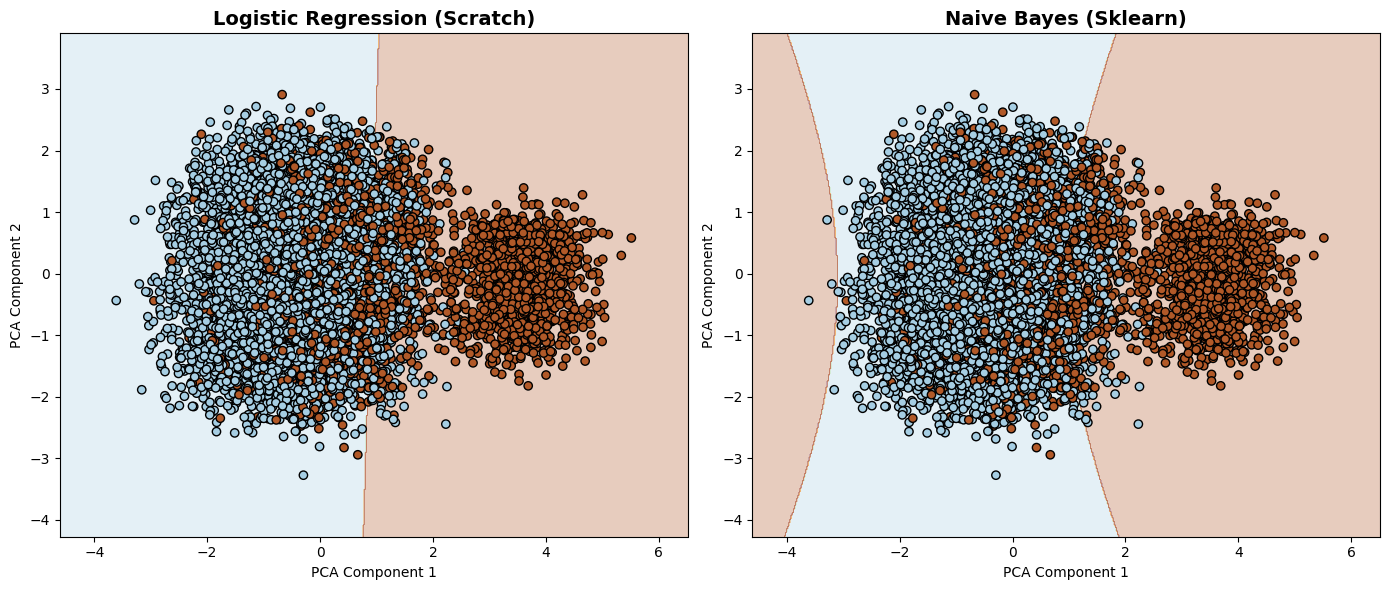

In [6]:
# استفاده از دو ویژگی عددی برای نمایش مرز تصمیم
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# آماده‌سازی داده‌ها با دو ویژگی عددی
def prepare_2d_data(df, target_col):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
    df_2d = df[numeric_cols].copy()
    y = (df[target_col] > 4).astype(int)
    scaler = StandardScaler()
    X_2d = scaler.fit_transform(df_2d)
    # کاهش بعد به ۲ بعد برای نمایش
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_2d)
    return X_2d, y.values

# تابع رسم مرز تصمیم
def plot_decision_boundary(X, y, models, titles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    for ax, model, title in zip(axes, models, titles):
        h = 0.02
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        mesh_points = np.c_[xx.ravel(), yy.ravel()]
        Z = model.predict(mesh_points)
        Z = Z.reshape(xx.shape)
        ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
        ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
        ax.set_title(title, fontsize=14, weight='bold')
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
    plt.tight_layout()
    plt.show()

# آماده‌سازی داده‌ها
X_2d, y_2d = prepare_2d_data(original_df, target)

# آموزش مدل‌ها
lr_scratch = LogisticRegression(lr=0.1, iterations=1000)
lr_scratch.fit(X_2d, y_2d)

nb_model = GaussianNB()
nb_model.fit(X_2d, y_2d)

# رسم مرز تصمیم
plot_decision_boundary(
    X_2d, y_2d,
    models=[lr_scratch, nb_model],
    titles=['Logistic Regression (Scratch)', 'Naive Bayes (Sklearn)']
)